In [79]:
import json
from pathlib import Path
from typing import Dict, Any

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.rcParams["figure.figsize"] = (10, 5)
pd.set_option("display.max_columns", 200)

In [100]:
# %%
BASE_DIR = Path("../assets/experiments/2026-03-10_21-07-34")

BALANCER_DIR = BASE_DIR / "baseline"
REPL_NO_ADAPT_DIR = BASE_DIR / "non_adaptive"
REPL_ADAPT_DIR = BASE_DIR / "adaptive"

print(BASE_DIR)

..\assets\experiments\2026-03-10_21-07-34


In [101]:
def load_experiment(path: Path) -> Dict[str, Any]:
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)

In [102]:
def extract_method(data):
    factors = data["factors"]

    balancer = factors.get("balancer")
    replication = factors.get("replication")
    adaptive = factors.get("adaptive")

    if replication:
        return f"{balancer} | {replication} | {'adaptive' if adaptive else 'no_adaptive'}"

    return f"{balancer} | no_replication"

In [103]:
# %%
def flatten_requests(data, method, group):
    rows = []

    for req in data["requests"]:

        upstream = req.get("upstream", {})
        signals = req.get("signals", {})

        sockets = upstream.get("sockets", [])
        winner = upstream.get("winner_socket")

        if sockets:
            replicas = len(sockets)
        else:
            replicas = 1

        rows.append({
            "method": method,
            "group": group,

            "req_id": req["req_id"],
            "endpoint": req["endpoint"],

            "latency_ms": req["latency_ms"],
            "status": req["status"],
            "ok": req["ok"],

            "winner_socket": winner,
            "replicas": replicas,

            "cpu_util": signals.get("cpu_util"),
            "mem_util": signals.get("mem_util"),
            "cpu_burn": signals.get("cpu_burn"),
            "mem_burn": signals.get("mem_burn"),
        })

    return pd.DataFrame(rows)

In [104]:
def load_folder(folder, group):
    dfs = []

    for file in folder.glob("*.json"):
        data = load_experiment(file)

        method = extract_method(data)

        df = flatten_requests(data, method, group)

        dfs.append(df)

    return dfs


dfs = []

dfs += load_folder(BALANCER_DIR, "balancer_only")
dfs += load_folder(REPL_NO_ADAPT_DIR, "replication_no_adaptive")
dfs += load_folder(REPL_ADAPT_DIR, "replication_adaptive")

df = pd.concat(dfs, ignore_index=True)

df.head()

,method,group,req_id,endpoint,latency_ms,status,ok,winner_socket,replicas,cpu_util,mem_util,cpu_burn,mem_burn
0,airm | no_replication,balancer_only,req-0,cpu?seconds=2,5498.5829,200,True,None,1,28.9,19.8,True,None
1,airm | no_replication,balancer_only,req-1,cpu?seconds=2,4634.4987,200,True,None,1,0.0,19.4,True,None
2,airm | no_replication,balancer_only,req-2,mem?seconds=2&mb=75,2151.8417,200,True,None,1,26.1,17.2,None,True
3,airm | no_replication,balancer_only,req-3,cpu?seconds=4,4091.4091,200,True,None,1,25.2,19.1,True,None
4,airm | no_replication,balancer_only,req-4,cpu?seconds=3,3130.9704,200,True,None,1,26.8,18.5,True,None


In [105]:
def p50(x):
    return np.percentile(x, 50)


def p95(x):
    return np.percentile(x, 95)


def p99(x):
    return np.percentile(x, 99)

# Latency

In [106]:
latency_stats = (
    df
    .groupby("method")["latency_ms"]
    .agg(
        mean="mean",
        p50=p50,
        p95=p95,
        p99=p99
    )
    .sort_values("mean")
)

latency_stats

,mean,p50,p95,p99
method,,,,
electre | speculative | adaptive,2710.249344,2577.57830,4551.887315,5242.681832
topsis | hedged | adaptive,2731.448558,2609.49830,4854.570520,5225.841436
topsis | speculative | adaptive,2741.461105,2616.59310,4925.768640,5239.457292
airm | speculative | adaptive,2767.426784,2595.83710,4721.362470,5243.723620
airm | hedged | adaptive,2796.822224,2623.26005,5100.871170,5238.695951
electre | hedged | adaptive,2800.456781,2622.65560,5209.438110,5251.694839
topsis | speculative | no_adaptive,2890.024800,2623.32455,5206.376700,5230.171634
airm | speculative | no_adaptive,2903.728101,2629.37565,5156.518600,5233.675204
airm | hedged | no_adaptive,2916.046089,2630.60690,5218.509285,5239.462950


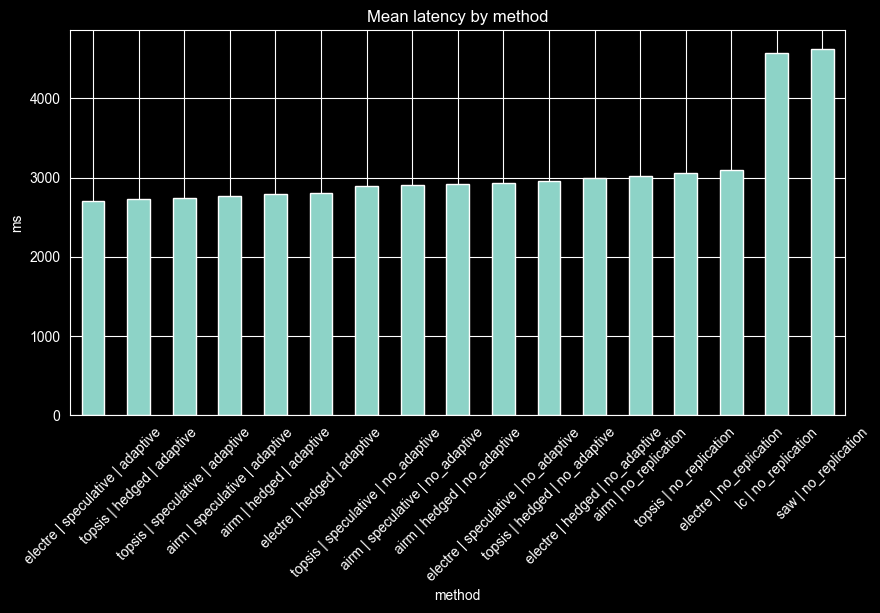

In [107]:
latency_stats["mean"].plot(kind="bar")

plt.title("Mean latency by method")
plt.ylabel("ms")
plt.xticks(rotation=45)

plt.show()

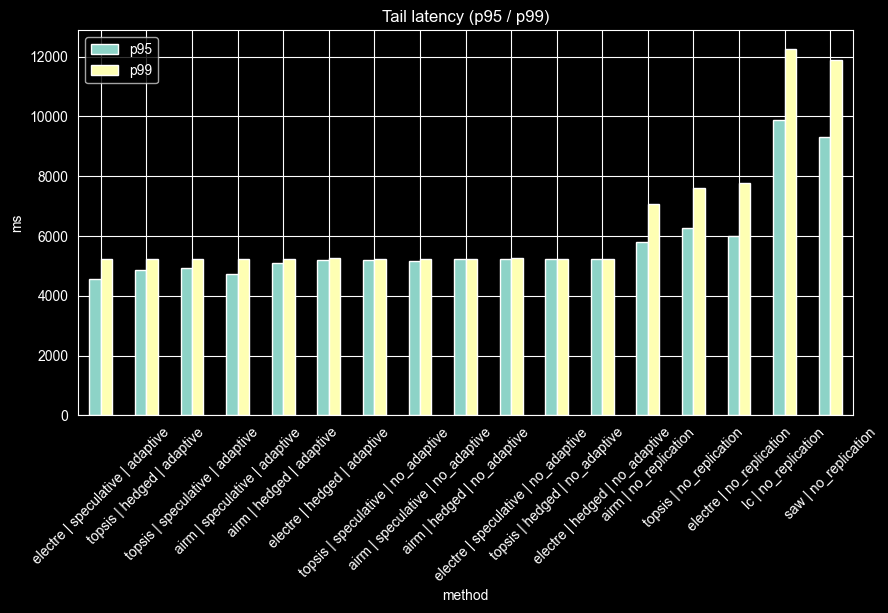

In [108]:
latency_stats[["p95", "p99"]].plot(kind="bar")

plt.title("Tail latency (p95 / p99)")
plt.ylabel("ms")
plt.xticks(rotation=45)

plt.show()

# WA

In [109]:
wa_stats = (
    df
    .groupby("method")["replicas"]
    .agg(
        mean="mean",
        p95=p95,
        max="max"
    )
    .sort_values("mean")
)

wa_stats

,mean,p95,max
method,,,
airm | no_replication,1.000,1.0,1
electre | no_replication,1.000,1.0,1
lc | no_replication,1.000,1.0,1
saw | no_replication,1.000,1.0,1
topsis | no_replication,1.000,1.0,1
topsis | hedged | adaptive,1.493,3.0,3
electre | speculative | adaptive,1.498,3.0,3
topsis | speculative | adaptive,1.500,3.0,3
electre | hedged | adaptive,1.535,3.0,3


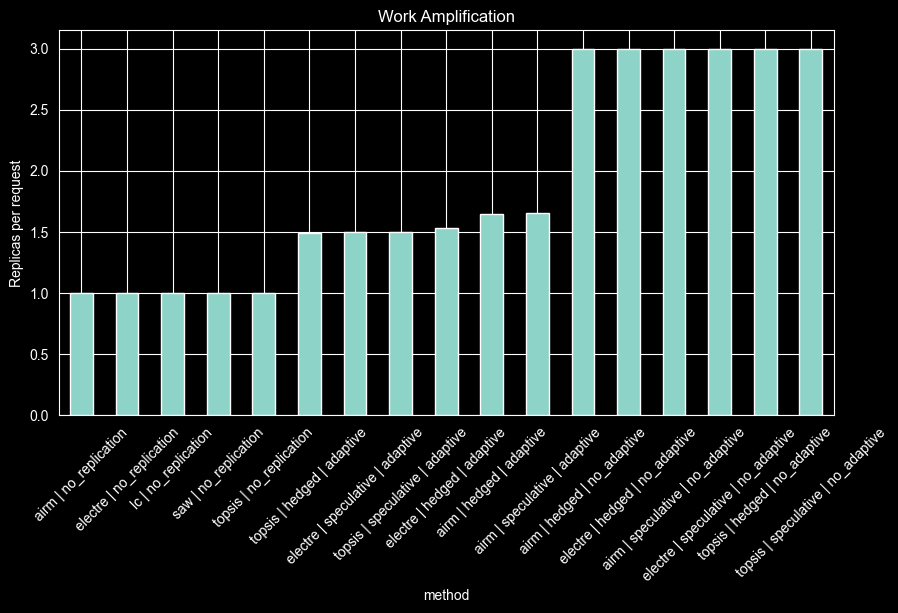

In [110]:
wa_stats["mean"].plot(kind="bar")

plt.title("Work Amplification")
plt.ylabel("Replicas per request")

plt.xticks(rotation=45)

plt.show()

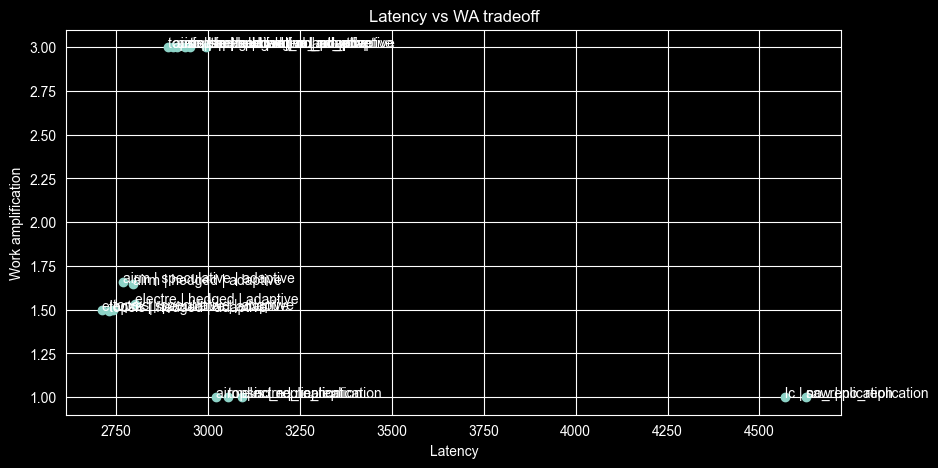

In [111]:
tradeoff = latency_stats.merge(
    wa_stats,
    left_index=True,
    right_index=True
)

plt.scatter(tradeoff["mean_x"], tradeoff["mean_y"])

for name, row in tradeoff.iterrows():
    plt.text(row["mean_x"], row["mean_y"], name)

plt.xlabel("Latency")
plt.ylabel("Work amplification")

plt.title("Latency vs WA tradeoff")

plt.show()

# CPU / MEM

In [112]:
socket_dist = (
    df
    .groupby(["method", "winner_socket"])
    .size()
    .reset_index(name="count")
)

socket_dist.head()

,method,winner_socket,count
0,airm | hedged | adaptive,,354
1,airm | hedged | adaptive,192.168.68.50_GQW_8001,17
2,airm | hedged | adaptive,192.168.68.50_GQW_8002,5
3,airm | hedged | adaptive,192.168.68.50_GQW_8003,13
4,airm | hedged | adaptive,192.168.68.50_GQW_8004,25


In [113]:
balance = (
    socket_dist
    .groupby("method")["count"]
    .agg(
        mean="mean",
        std="std"
    )
)

balance["cv"] = balance["std"] / balance["mean"]

balance.sort_values("cv")

,mean,std,cv
method,,,
electre | speculative | adaptive,26.315789,45.981844,1.747310
airm | speculative | adaptive,26.315789,55.147520,2.095606
electre | hedged | adaptive,26.315789,55.871041,2.123100
topsis | hedged | adaptive,23.809524,52.252781,2.194617
topsis | speculative | adaptive,25.641026,57.111842,2.227362
airm | hedged | adaptive,23.255814,53.619956,2.305658
airm | speculative | no_adaptive,23.255814,81.787498,3.516862
topsis | speculative | no_adaptive,23.809524,93.911541,3.944285
electre | speculative | no_adaptive,23.255814,95.318787,4.098708


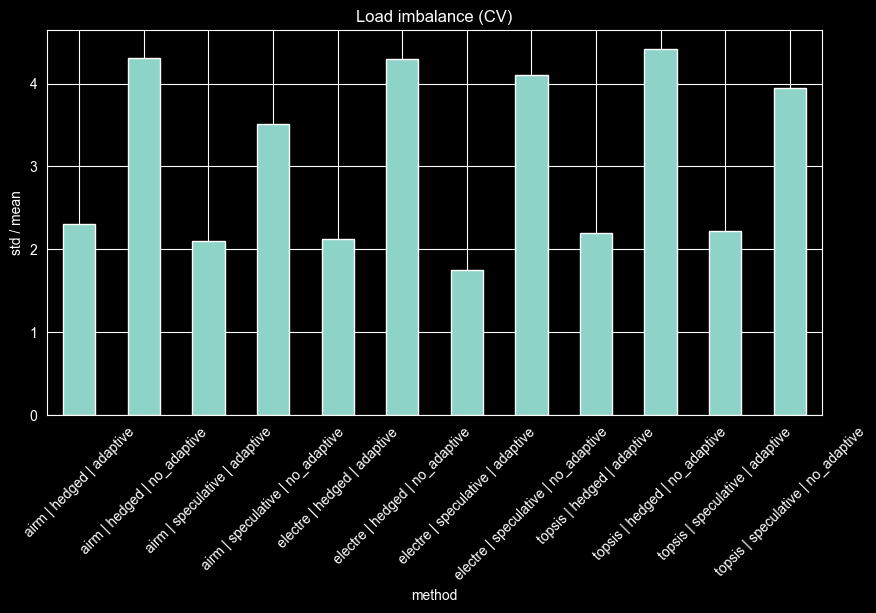

In [114]:
balance["cv"].plot(kind="bar")

plt.title("Load imbalance (CV)")
plt.ylabel("std / mean")

plt.xticks(rotation=45)

plt.show()

In [115]:
lat_by_group = (
    df
    .groupby("group")["latency_ms"]
    .mean()
)

lat_by_group

group
balancer_only              3672.833473
replication_adaptive       2757.977466
replication_no_adaptive    2931.947933
Name: latency_ms, dtype: float64

In [116]:
baseline = lat_by_group["balancer_only"]

rep_no = lat_by_group["replication_no_adaptive"]

rep_ad = lat_by_group["replication_adaptive"]

print("Replication improvement:",
      (baseline - rep_no) / baseline * 100)

Replication improvement: 20.172042804716167


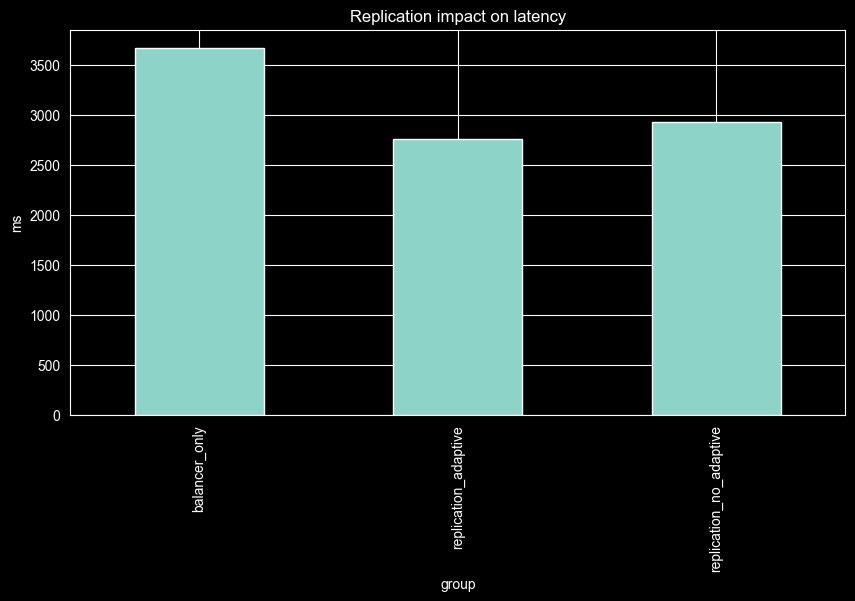

In [117]:
# %%
lat_by_group.plot(kind="bar")

plt.title("Replication impact on latency")

plt.ylabel("ms")

plt.show()

# Выгода адаптивности

In [118]:
wa_group = (
    df
    .groupby("group")["replicas"]
    .mean()
)

wa_group

group
balancer_only              1.000
replication_adaptive       1.555
replication_no_adaptive    3.000
Name: replicas, dtype: float64

In [119]:
adaptive_gain = (
                        (wa_group["replication_no_adaptive"]
                         - wa_group["replication_adaptive"])

                        / wa_group["replication_no_adaptive"]

                ) * 100

print("Adaptive WA reduction:", adaptive_gain)

Adaptive WA reduction: 48.16666666666667


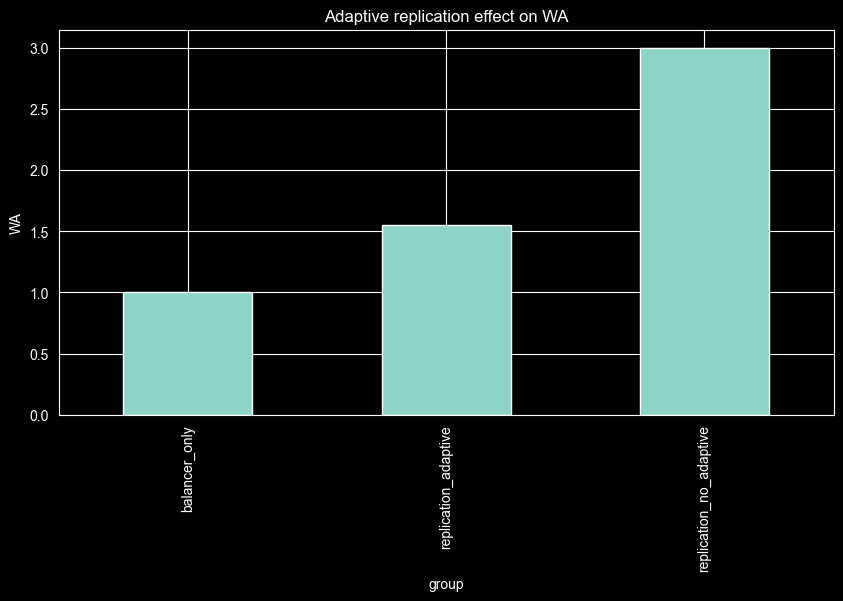

In [120]:
wa_group.plot(kind="bar")

plt.title("Adaptive replication effect on WA")

plt.ylabel("WA")

plt.show()

# CPU vs MEM Latency

In [121]:
df["is_cpu"] = df["endpoint"].str.startswith("cpu")

lat_cpu_mem = (

    df
    .groupby(["method","is_cpu"])["latency_ms"]
    .mean()
    .unstack()
)

lat_cpu_mem

is_cpu,False,True
method,,
airm | hedged | adaptive,2907.820359,2694.362407
airm | hedged | no_adaptive,2925.542283,2906.775102
airm | no_replication,3305.327540,2721.081064
airm | speculative | adaptive,2835.319818,2690.866554
airm | speculative | no_adaptive,3018.246022,2790.576198
electre | hedged | adaptive,2925.959250,2685.533064
electre | hedged | no_adaptive,3115.533673,2875.510967
electre | no_replication,3335.521533,2855.658973
electre | speculative | adaptive,2786.451435,2630.936964


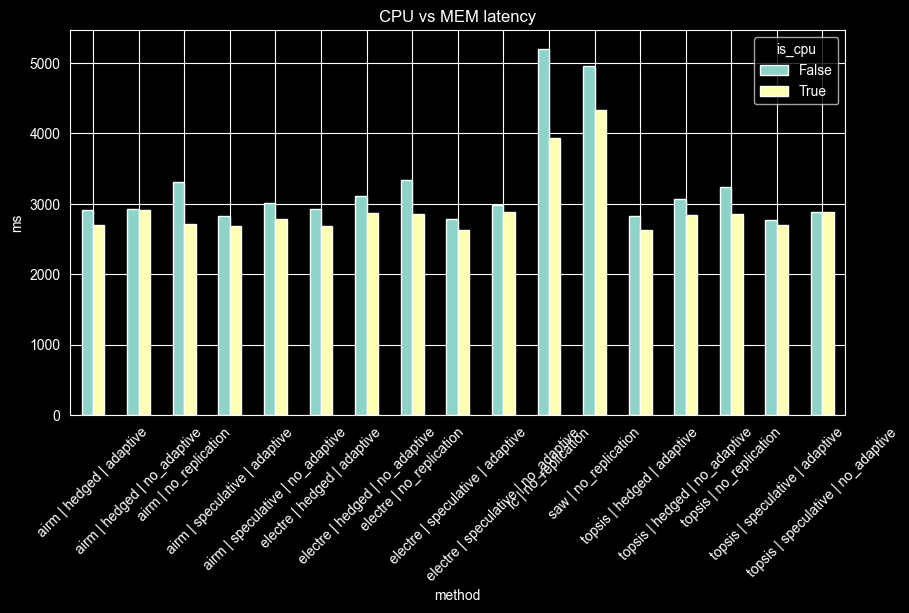

In [122]:
lat_cpu_mem.plot(kind="bar")

plt.title("CPU vs MEM latency")

plt.ylabel("ms")

plt.xticks(rotation=45)

plt.show()

In [123]:
best_mean = latency_stats["mean"].idxmin()
best_p95 = latency_stats["p95"].idxmin()
best_wa = wa_stats["mean"].idxmin()

print("Best mean latency:", best_mean)
print("Best p95 latency:", best_p95)
print("Best WA:", best_wa)

Best mean latency: electre | speculative | adaptive
Best p95 latency: electre | speculative | adaptive
Best WA: airm | no_replication
